# Домашнее задание №6

**Классификация облаков**

**Студент** Сизиков Константин Александрович

## Цель:
Неглубокие облака играют огромную роль в определении климата Земли, но их трудно распознать и классифицировать в климатических моделях. Классифицируя различные типы организации облаков, исследователи из Института Макса Планка надеются улучшить наше физическое понимание этих облаков, что, в свою очередь, поможет нам построить более совершенные климатические модели.

Существует множество способов организации облаков, но границы между различными формами организации нечеткие. Это затрудняет построение традиционных алгоритмов, основанных на правилах, для разделения облачных характеристик. Однако человеческий глаз отлично справляется с обнаружением особенностей - например, облаков, похожих на цветы.

В этом задании вам предстоит построить модель для классификации моделей организации облаков на спутниковых снимках. В случае успеха вы поможете ученым лучше понять, как облака будут определять наш будущий климат.


## Описание/Пошаговая инструкция выполнения домашнего задания:
 - сформировать нейронную сверточную сеть;
 - обучить сеть на представленных данных;
 - оценить качество модели. В качестве критерия используйте Dice coefficient.
 - датасет для обучения модели: https://drive.google.com/file/d/1leoj71B_D_paBLC1uP5EKcnR5lJFPovn/view

Сравниваются четыре модели:

1. **SimpleCNN** — свёрточная сеть, обучаемая с нуля, без
   предобученных весов;
2. **ResNet18** (transfer learning) — backbone, предобученный на ImageNet, с
   заменённой полносвязной головой под 4 класса, дообучаемый полностью
   (fine-tuning);
3. **ViT-B/16** (Vision Transformer, transfer learning) — трансформерный
   backbone `torchvision.models.vit_b_16` с весами `IMAGENET1K_SWAG_E2E_V1`,
   с заменённой головой под 4 класса, дообучаемый на разрешении 384×384;
4. **ConvNeXt-V2-Base** (transfer learning) — современная свёрточная
   архитектура `timm` (`convnextv2_base.fcmae_ft_in22k_in1k_384`).

Для всех четырёх моделей используется один и тот же цикл обучения с ранней
остановкой по Dice coefficient на валидации, что позволяет честно сравнить
качество «сеть с нуля» vs «перенос обучения (CNN)» vs «перенос обучения
(трансформер)» vs «перенос обучения (современная CNN)».

In [1]:
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights
import timm

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3090


In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "understanding_cloud_organization"
IMG_DIR = DATA_DIR / "train_images"
CSV_PATH = DATA_DIR / "train.csv"

CLASSES = ["Fish", "Flower", "Gravel", "Sugar"]
COLORS = {"Fish": "#0072B2", "Flower": "#E69F00", "Gravel": "#009E73", "Sugar": "#D55E00"}
NUM_CLASSES = len(CLASSES)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

assert DATA_DIR.exists(), f"Не найдена папка с данными: {DATA_DIR}"
print("Train images dir:", IMG_DIR)

Train images dir: /home/ubuntu/projects/ml/machine_learning_professional/hw_06/understanding_cloud_organization/train_images


## 1. Подготовка данных

Исходный `train.csv` соревнования размечен построчно: одна строка — одна
пара (изображение, класс) с RLE-маской (или `NaN`, если класса на снимке
нет). Разворачиваем это в таблицу `labels_df`: одна строка на изображение,
колонки — бинарные метки наличия каждого из 4 классов.

In [3]:
df = pd.read_csv(CSV_PATH)
df[["Image", "Label"]] = df["Image_Label"].str.split("_", expand=True)
df["HasMask"] = df["EncodedPixels"].notna()

labels_df = df.pivot(index="Image", columns="Label", values="HasMask").fillna(False)
labels_df = labels_df[CLASSES].astype(int)

print(f"Всего снимков: {len(labels_df)}")
labels_df.head()

Всего снимков: 5546


Label,Fish,Flower,Gravel,Sugar
Image,,,,
0011165.jpg,1,1,0,0
002be4f.jpg,1,1,0,1
0031ae9.jpg,1,1,0,1
0035239.jpg,0,1,1,0
003994e.jpg,1,0,1,1


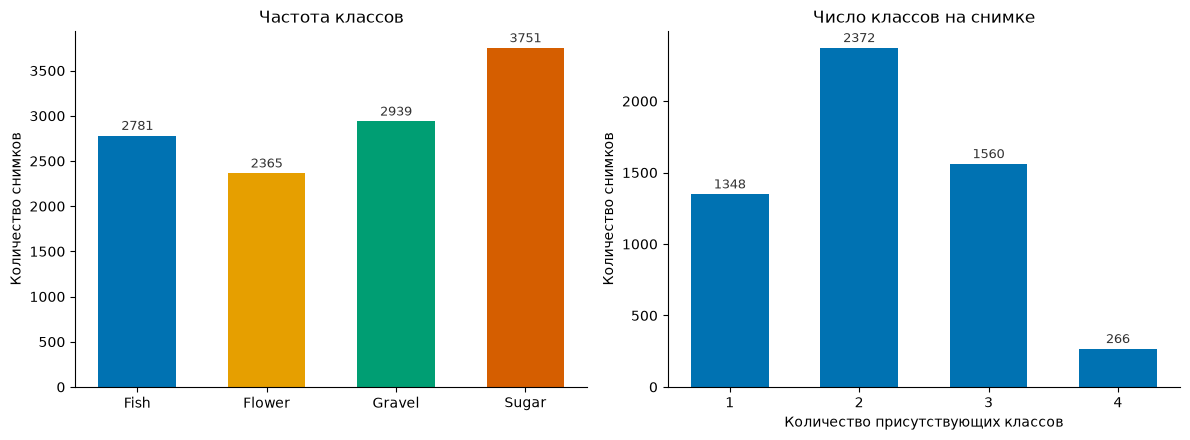

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

class_counts = labels_df.sum().reindex(CLASSES)
axes[0].bar(class_counts.index, class_counts.values,
            color=[COLORS[c] for c in CLASSES], width=0.6)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", va="bottom", fontsize=9, color="#333333")
axes[0].set_title("Частота классов")
axes[0].set_ylabel("Количество снимков")
axes[0].spines[["top", "right"]].set_visible(False)

label_counts = labels_df.sum(axis=1).value_counts().sort_index()
axes[1].bar(label_counts.index.astype(str), label_counts.values, color="#0072B2", width=0.6)
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center", va="bottom", fontsize=9, color="#333333")
axes[1].set_title("Число классов на снимке")
axes[1].set_xlabel("Количество присутствующих классов")
axes[1].set_ylabel("Количество снимков")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Быстрая проверка на исходных данных: декодируем RLE-маски и отрисуем их
контуром на нескольких снимках, чтобы убедиться, что метки соответствуют
содержимому изображений.

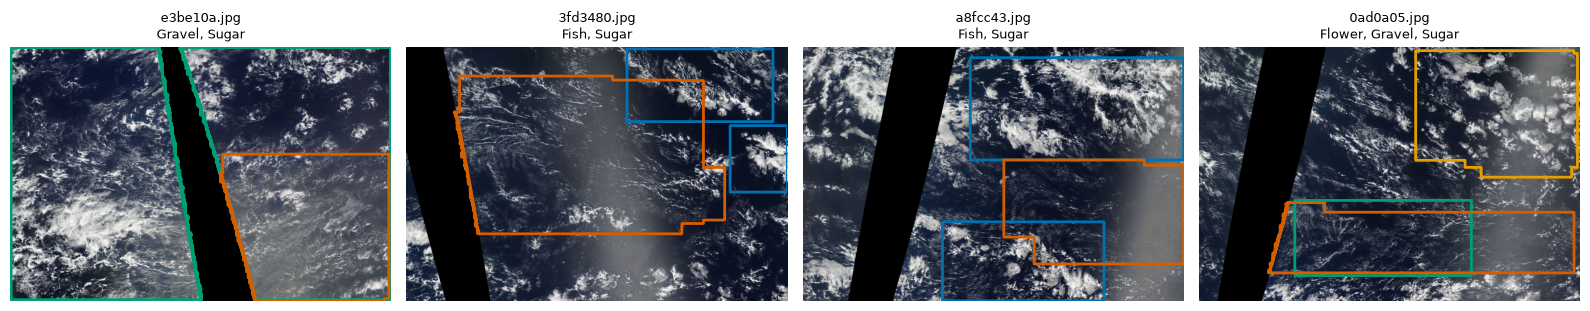

In [5]:
def rle_decode(mask_rle, shape=(1400, 2100)):
    '''Декодирует RLE-строку соревнования в бинарную маску (height, width).'''
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    s = mask_rle.split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends = starts + lengths
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        mask[lo:hi] = 1
    return mask.reshape(shape, order="F")


def show_sample(image_id, ax):
    img = Image.open(IMG_DIR / image_id)
    ax.imshow(img)
    present = []
    for _, row in df[df["Image"] == image_id].iterrows():
        if row["HasMask"]:
            mask = rle_decode(row["EncodedPixels"])
            ax.contour(mask, levels=[0.5], colors=[COLORS[row["Label"]]], linewidths=2)
            present.append(row["Label"])
    ax.set_title(f"{image_id}\n{', '.join(present)}", fontsize=9)
    ax.axis("off")


sample_ids = np.random.RandomState(SEED).choice(labels_df.index.values, size=4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for image_id, ax in zip(sample_ids, axes):
    show_sample(image_id, ax)
plt.tight_layout()
plt.show()

## 2. Train / validation split

Разбиваем изображения на train/val со стратификацией по комбинации
присутствующих классов (`combo_key`), чтобы редкие сочетания классов не
сосредоточились целиком в одной из выборок.

train: 4714 снимков, val: 832 снимков


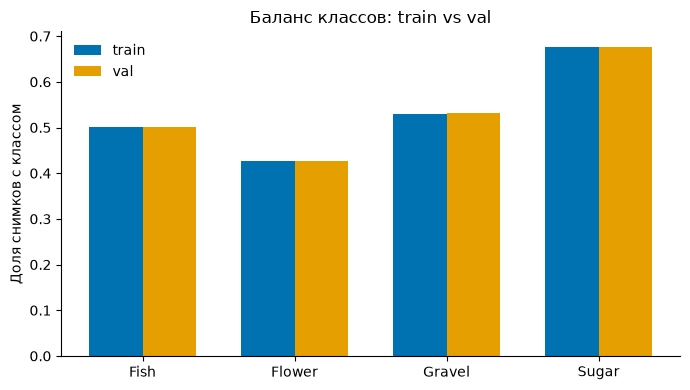

In [6]:
combo_key = labels_df.apply(lambda r: "".join(r.astype(str)), axis=1)

train_ids, val_ids = train_test_split(
    labels_df.index.values,
    test_size=0.15,
    random_state=SEED,
    stratify=combo_key,
)
print(f"train: {len(train_ids)} снимков, val: {len(val_ids)} снимков")

train_labels = labels_df.loc[train_ids]
val_labels = labels_df.loc[val_ids]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(CLASSES))
width = 0.35
ax.bar(x - width / 2, train_labels[CLASSES].mean(), width, label="train", color="#0072B2")
ax.bar(x + width / 2, val_labels[CLASSES].mean(), width, label="val", color="#E69F00")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Доля снимков с классом")
ax.set_title("Баланс классов: train vs val")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Dataset и DataLoader

Аугментация для train — случайные отражения и лёгкий color jitter (облачные
текстуры не имеют выделенной ориентации, поэтому вертикальный/горизонтальный
flip допустимы). Нормализация — статистики ImageNet, так как одна из моделей
использует предобученный на ImageNet backbone.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class CloudsDataset(Dataset):
    def __init__(self, image_ids, labels_df, img_dir, transform):
        self.image_ids = list(image_ids)
        self.labels_df = labels_df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img = Image.open(self.img_dir / image_id).convert("RGB")
        img = self.transform(img)
        target = torch.tensor(self.labels_df.loc[image_id].values, dtype=torch.float32)
        return img, target


train_ds = CloudsDataset(train_ids, train_labels, IMG_DIR, train_tf)
val_ds = CloudsDataset(val_ids, val_labels, IMG_DIR, val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

imgs, tgts = next(iter(train_loader))
print("batch images:", imgs.shape, "batch targets:", tgts.shape)

batch images: torch.Size([32, 3, 224, 224]) batch targets: torch.Size([32, 4])


## 4. Модель 1: SimpleCNN — свёрточная сеть с нуля

Небольшая VGG-подобная сеть без предобученных весов: 5 свёрточных блоков
(`Conv → BatchNorm → ReLU`, дважды на блок) с уменьшением пространственного
размера `MaxPool2d` между блоками, затем `AdaptiveAvgPool2d` и полносвязная
голова с `Dropout` под 4 класса. Обучается полностью с нуля без переноса обучения.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)


def build_simple_cnn():
    return SimpleCNN().to(DEVICE)


_test_model = build_simple_cnn()
_test_out = _test_model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print("SimpleCNN sanity check output shape:", _test_out.shape)
del _test_model, _test_out

SimpleCNN sanity check output shape: torch.Size([2, 4])


## 5. Модель 2: ResNet18 — перенос обучения (transfer learning)

Backbone `resnet18`, предобученный на ImageNet, с заменённым последним
`Linear`-слоем (`fc`) под 4 класса. Дообучаем **все** веса сети (полный
fine-tuning), а не только голову — при небольшом `lr` это даёт лучшее
качество, чем заморозка backbone, за счёт адаптации низкоуровневых фильтров
под текстуры облаков со спутника.

In [9]:
def build_resnet18(num_classes=NUM_CLASSES):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


_test_model = build_resnet18()
_test_out = _test_model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print("ResNet18 sanity check output shape:", _test_out.shape)
del _test_model, _test_out

ResNet18 sanity check output shape: torch.Size([2, 4])


## 6. Модель 3: ViT-B/16 — Vision Transformer (transfer learning)

В качестве трансформерной архитектуры берём `vit_b_16` из `torchvision` с
весами `ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1` — это чекпоинт из проекта
Meta AI **SWAG** (*Supervised Weakly from hashtAGs*): модель предобучена на
~3.6 млрд изображений Instagram со слабой разметкой по хэштегам, а затем
дообучена end-to-end на ImageNet-1K при разрешении 384×384. Это даёт
**85.3% top-1 accuracy** на ImageNet — заметно выше, чем у базовых весов
`IMAGENET1K_V1` (81.1%) или линейного проб-варианта `SWAG_LINEAR_V1` (81.9%),
и одни из лучших общедоступных весов ViT-B/16 в `torchvision`.

Особенность этих весов — они **привязаны к разрешению 384×384**, тогда как
SimpleCNN и ResNet18 обучаются на 224×224. Поэтому для ViT заводим отдельный
набор трансформаций и `DataLoader`, использующие исходные `train_ids` /
`val_ids` (тот же train/val split, что и для остальных моделей — сравнение
остаётся честным), но с другим размером изображения и бикубической
интерполяцией (как в оригинальном рецепте SWAG). Голову классификатора
(`model.heads`) заменяем на `Linear(hidden_dim, 4)` и дообучаем **всю** сеть
целиком (полный fine-tuning), как и ResNet18.

In [10]:
VIT_IMG_SIZE = 384  # родное разрешение весов IMAGENET1K_SWAG_E2E_V1
VIT_BATCH_SIZE = 32

vit_train_tf = T.Compose([
    T.Resize((VIT_IMG_SIZE, VIT_IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

vit_val_tf = T.Compose([
    T.Resize((VIT_IMG_SIZE, VIT_IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds_vit = CloudsDataset(train_ids, train_labels, IMG_DIR, vit_train_tf)
val_ds_vit = CloudsDataset(val_ids, val_labels, IMG_DIR, vit_val_tf)

train_loader_vit = DataLoader(train_ds_vit, batch_size=VIT_BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_vit = DataLoader(val_ds_vit, batch_size=VIT_BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

imgs_vit, tgts_vit = next(iter(train_loader_vit))
print("ViT batch images:", imgs_vit.shape, "batch targets:", tgts_vit.shape)


def build_vit(num_classes=NUM_CLASSES):
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1, image_size=VIT_IMG_SIZE)
    model.heads = nn.Linear(model.hidden_dim, num_classes)
    return model.to(DEVICE)


_test_model = build_vit()
_test_out = _test_model(torch.randn(2, 3, VIT_IMG_SIZE, VIT_IMG_SIZE).to(DEVICE))
print("ViT-B/16 sanity check output shape:", _test_out.shape)
del _test_model, _test_out

ViT batch images: torch.Size([32, 3, 384, 384]) batch targets: torch.Size([32, 4])


ViT-B/16 sanity check output shape: torch.Size([2, 4])


## 7. Модель 4: ConvNeXt-V2-Base — современная свёрточная сеть (transfer learning)

`torchvision` не содержит ConvNeXt-V2, поэтому для этой архитектуры
используется `timm`. Чекпоинт `convnextv2_base.fcmae_ft_in22k_in1k_384`:
self-supervised предобучение **FCMAE** (Fully Convolutional Masked
AutoEncoder) на ImageNet, затем дообучение на ImageNet-22k и ImageNet-1k при
разрешении 384×384 — **87.7% top-1**, выше, чем у весов ViT-B/16 SWAG
(85.3%), использованных для модели 3.

Препроцессинг этого чекпоинта (`input_size=384`, `crop_pct=1.0`, бикубическая
интерполяция, статистики ImageNet) совпадает с уже заведённым для ViT
пайплайном, поэтому переиспользуем те же датасеты (`train_ds_vit` /
`val_ds_vit`) — сравнение с ViT-B/16 идёт на одинаковом разрешении и
одинаковых аугментациях. Для валидации хватает общего `val_loader_vit`
(инференс дёшев по памяти), а для обучения заводим отдельный
`train_loader_convnext` с батчем поменьше — полный fine-tuning
ConvNeXt-V2-Base на 384px существенно тяжелее по активациям, чем ViT-B/16, и
с тем же батчем 32 не помещается в 24GB VRAM. Голову классификатора
заменяем на `Linear(in_features, 4)` через `num_classes=NUM_CLASSES` в
`timm.create_model` и дообучаем сеть целиком (полный fine-tuning), как
ResNet18 и ViT-B/16.

В отличие от ViT, ConvNeXt-V2 — свёрточная архитектура: свёртки по своей
природе локальны и трансляционно-инвариантны, что должно быть выигрышным для
текстурных паттернов организации облаков (`Fish`/`Flower`/`Gravel`/`Sugar`)
и потенциально даёт лучшую устойчивость к переобучению на выборке из ~4.7к
train-снимков, чем self-attention ViT.

In [11]:
CONVNEXT_V2_NAME = "convnextv2_base.fcmae_ft_in22k_in1k_384"
CONVNEXT_TRAIN_BATCH_SIZE = 16  # ConvNeXt-V2-Base на 384px существенно тяжелее ViT-B/16 по активациям
                                # при обучении (полный fine-tuning): batch=32 не помещается в 24GB VRAM,
                                # тогда как для инференса (val_loader_vit) хватает и batch=32.

train_loader_convnext = DataLoader(train_ds_vit, batch_size=CONVNEXT_TRAIN_BATCH_SIZE, shuffle=True,
                                    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)


def build_convnext_v2(num_classes=NUM_CLASSES):
    model = timm.create_model(CONVNEXT_V2_NAME, pretrained=True, num_classes=num_classes)
    return model.to(DEVICE)


_test_model = build_convnext_v2()
_test_out = _test_model(torch.randn(2, 3, VIT_IMG_SIZE, VIT_IMG_SIZE).to(DEVICE))
print("ConvNeXt-V2 sanity check output shape:", _test_out.shape)
print(f"ConvNeXt-V2 params: {sum(p.numel() for p in _test_model.parameters()) / 1e6:.1f}M")
del _test_model, _test_out

ConvNeXt-V2 sanity check output shape: torch.Size([2, 4])
ConvNeXt-V2 params: 87.7M


## 8. Метрика: Dice coefficient

Для multi-label классификации Dice coefficient считается по бинарному
вектору присутствия классов (после порогового бинаризации сигмоиды при
`0.5`):

$$Dice = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Считаем две версии:
- **sample-wise** (усреднённая по снимкам) — используется как основная
  метрика и критерий ранней остановки;
- **per-class** (усреднённая по классам) — для финального сравнения моделей.

In [12]:
def dice_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    '''Средний по батчу sample-wise Dice coefficient.'''
    preds = (torch.sigmoid(logits) > threshold).float()
    intersection = (preds * targets).sum(dim=1)
    denom = preds.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (denom + eps)
    return dice.mean().item()


def per_class_dice(all_logits, all_targets, threshold=0.5, eps=1e-7):
    '''Dice coefficient отдельно для каждого класса (по всей выборке).'''
    preds = (torch.sigmoid(all_logits) > threshold).float()
    tp = (preds * all_targets).sum(dim=0)
    denom = preds.sum(dim=0) + all_targets.sum(dim=0)
    dice = (2 * tp + eps) / (denom + eps)
    return {c: d.item() for c, d in zip(CLASSES, dice)}

## 9. Цикл обучения с ранней остановкой по Dice

Собственный цикл обучения на чистом PyTorch: `BCEWithLogitsLoss` (multi-label)
+ `AdamW` + косинусный scheduler. После каждой эпохи считается Dice
coefficient на валидации; если метрика не улучшается `patience` эпох подряд —
обучение останавливается, а модели возвращаются веса **лучшей по Dice**
эпохи (не последней).

In [13]:
def train_model(model, train_loader, val_loader, name,
                 max_epochs=30, patience=5, lr=1e-3, weight_decay=1e-4):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    history = {"train_loss": [], "val_loss": [], "val_dice": []}
    best_dice, best_epoch, best_state = -1.0, -1, None
    epochs_no_improve = 0
    start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, tgts in train_loader:
            imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, tgts)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        scheduler.step()

        model.eval()
        val_running_loss, val_dice_sum, n_val = 0.0, 0.0, 0
        with torch.no_grad():
            for imgs, tgts in val_loader:
                imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
                logits = model(imgs)
                loss = criterion(logits, tgts)
                val_running_loss += loss.item() * imgs.size(0)
                val_dice_sum += dice_from_logits(logits, tgts) * imgs.size(0)
                n_val += imgs.size(0)
        val_loss = val_running_loss / n_val
        val_dice = val_dice_sum / n_val

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)

        improved = val_dice > best_dice
        if improved:
            best_dice, best_epoch = val_dice, epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        marker = " *" if improved else ""
        print(f"[{name}] epoch {epoch:02d}/{max_epochs} "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
              f"val_dice={val_dice:.4f}{marker}")

        if epochs_no_improve >= patience:
            print(f"[{name}] early stopping: Dice не улучшается {patience} эпох подряд "
                  f"(лучшая эпоха {best_epoch}, val_dice={best_dice:.4f})")
            break

    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    history["best_dice"] = best_dice
    history["n_params"] = sum(p.numel() for p in model.parameters())
    history["train_time_sec"] = time.time() - start
    return model, history

## 10. Обучение модели 1 — SimpleCNN (с нуля)

Больший `lr` и больше эпох, т.к. сеть без предобученных весов сходится
медленнее.

In [14]:
torch.manual_seed(SEED)
model_cnn = build_simple_cnn()
model_cnn, history_cnn = train_model(
    model_cnn, train_loader, val_loader,
    name="SimpleCNN", max_epochs=30, patience=6, lr=1e-3,
)

[SimpleCNN] epoch 01/30 train_loss=0.6076 val_loss=0.7818 val_dice=0.5993 *


[SimpleCNN] epoch 02/30 train_loss=0.5716 val_loss=0.5657 val_dice=0.7103 *


[SimpleCNN] epoch 03/30 train_loss=0.5615 val_loss=0.6710 val_dice=0.6992


[SimpleCNN] epoch 04/30 train_loss=0.5552 val_loss=0.5351 val_dice=0.7364 *


[SimpleCNN] epoch 05/30 train_loss=0.5465 val_loss=0.5506 val_dice=0.7171


...

[SimpleCNN] epoch 26/30 train_loss=0.4778 val_loss=0.4827 val_dice=0.7694 *


[SimpleCNN] epoch 27/30 train_loss=0.4792 val_loss=0.4853 val_dice=0.7628


[SimpleCNN] epoch 28/30 train_loss=0.4789 val_loss=0.4845 val_dice=0.7673


[SimpleCNN] epoch 29/30 train_loss=0.4766 val_loss=0.4829 val_dice=0.7665


[SimpleCNN] epoch 30/30 train_loss=0.4749 val_loss=0.4821 val_dice=0.7690


## 11. Обучение модели 2 — ResNet18 (transfer learning)

Те же данные, та же аугментация, тот же алгоритм обучения.
Отличие в архитектуре и стартовых весах. Меньший `lr`, так как backbone уже
предобучен и его не нужно «ломать» большими градиентными шагами.

In [15]:
torch.manual_seed(SEED)
model_resnet = build_resnet18()
model_resnet, history_resnet = train_model(
    model_resnet, train_loader, val_loader,
    name="ResNet18", max_epochs=30, patience=6, lr=1e-4,
)

[ResNet18] epoch 01/30 train_loss=0.5604 val_loss=0.5272 val_dice=0.7446 *


[ResNet18] epoch 02/30 train_loss=0.5010 val_loss=0.5203 val_dice=0.7407


[ResNet18] epoch 03/30 train_loss=0.4680 val_loss=0.5054 val_dice=0.7502 *


[ResNet18] epoch 04/30 train_loss=0.4383 val_loss=0.5169 val_dice=0.7432


[ResNet18] epoch 05/30 train_loss=0.4015 val_loss=0.5490 val_dice=0.7421


[ResNet18] epoch 06/30 train_loss=0.3677 val_loss=0.5659 val_dice=0.7318


[ResNet18] epoch 07/30 train_loss=0.3286 val_loss=0.5749 val_dice=0.7316


[ResNet18] epoch 08/30 train_loss=0.2882 val_loss=0.6037 val_dice=0.7259


[ResNet18] epoch 09/30 train_loss=0.2361 val_loss=0.6057 val_dice=0.7356
[ResNet18] early stopping: Dice не улучшается 6 эпох подряд (лучшая эпоха 3, val_dice=0.7502)


## 12. Обучение модели 3 — ViT-B/16 (fine-tuning)

Тот же `train_model`, но со своими `train_loader_vit` / `val_loader_vit`
(384×384) и ещё меньшим `lr` — трансформеры без предобученных на данный
домен признаков «ломаются» слишком большим шагом легче, чем свёрточные сети,
а сама модель уже достаточно сильна за счёт масштабного предобучения.

In [16]:
torch.manual_seed(SEED)
model_vit = build_vit()
model_vit, history_vit = train_model(
    model_vit, train_loader_vit, val_loader_vit,
    name="ViT-B/16", max_epochs=15, patience=4, lr=2e-5,
)

[ViT-B/16] epoch 01/15 train_loss=0.5785 val_loss=0.5110 val_dice=0.7259 *


[ViT-B/16] epoch 02/15 train_loss=0.5010 val_loss=0.5238 val_dice=0.7355 *


[ViT-B/16] epoch 03/15 train_loss=0.4736 val_loss=0.5073 val_dice=0.7610 *


[ViT-B/16] epoch 04/15 train_loss=0.4460 val_loss=0.4886 val_dice=0.7730 *


[ViT-B/16] epoch 05/15 train_loss=0.4172 val_loss=0.4805 val_dice=0.7700


[ViT-B/16] epoch 06/15 train_loss=0.3734 val_loss=0.5353 val_dice=0.7554


[ViT-B/16] epoch 07/15 train_loss=0.3296 val_loss=0.5545 val_dice=0.7653


[ViT-B/16] epoch 08/15 train_loss=0.2774 val_loss=0.6516 val_dice=0.7484
[ViT-B/16] early stopping: Dice не улучшается 4 эпох подряд (лучшая эпоха 4, val_dice=0.7730)


## 13. Обучение модели 4 — ConvNeXt-V2-Base (fine-tuning)

Валидация — на общем `val_loader_vit` (384×384, batch=32), а для обучения используется отдельный `train_loader_convnext` с
батчем поменьше (`16` вместо `32`): полный fine-tuning ConvNeXt-V2-Base на
384px существенно тяжелее по активациям, чем ViT-B/16, и с батчем 32 не
помещается в 24GB VRAM. `lr` выбран между значениями для ResNet18 и ViT:
ConvNeXt-V2 — свёрточная сеть (более устойчива к большому `lr`, чем
трансформер), но с более сильным и специфичным предобучением (FCMAE +
ImageNet-22k), которое не хочется разрушать за первые же шаги.

In [17]:
torch.manual_seed(SEED)
model_convnext = build_convnext_v2()
model_convnext, history_convnext = train_model(
    model_convnext, train_loader_convnext, val_loader_vit,
    name="ConvNeXt-V2", max_epochs=15, patience=4, lr=5e-5,
)

[ConvNeXt-V2] epoch 01/15 train_loss=0.5553 val_loss=0.5080 val_dice=0.7573 *


[ConvNeXt-V2] epoch 02/15 train_loss=0.4876 val_loss=0.4901 val_dice=0.7605 *


[ConvNeXt-V2] epoch 03/15 train_loss=0.4581 val_loss=0.4949 val_dice=0.7581


[ConvNeXt-V2] epoch 04/15 train_loss=0.4313 val_loss=0.4976 val_dice=0.7679 *


[ConvNeXt-V2] epoch 05/15 train_loss=0.3831 val_loss=0.5060 val_dice=0.7652


[ConvNeXt-V2] epoch 06/15 train_loss=0.3305 val_loss=0.5811 val_dice=0.7609


[ConvNeXt-V2] epoch 07/15 train_loss=0.2607 val_loss=0.5867 val_dice=0.7417


[ConvNeXt-V2] epoch 08/15 train_loss=0.1853 val_loss=0.6808 val_dice=0.7388
[ConvNeXt-V2] early stopping: Dice не улучшается 4 эпох подряд (лучшая эпоха 4, val_dice=0.7679)


## 14. Графики обучения

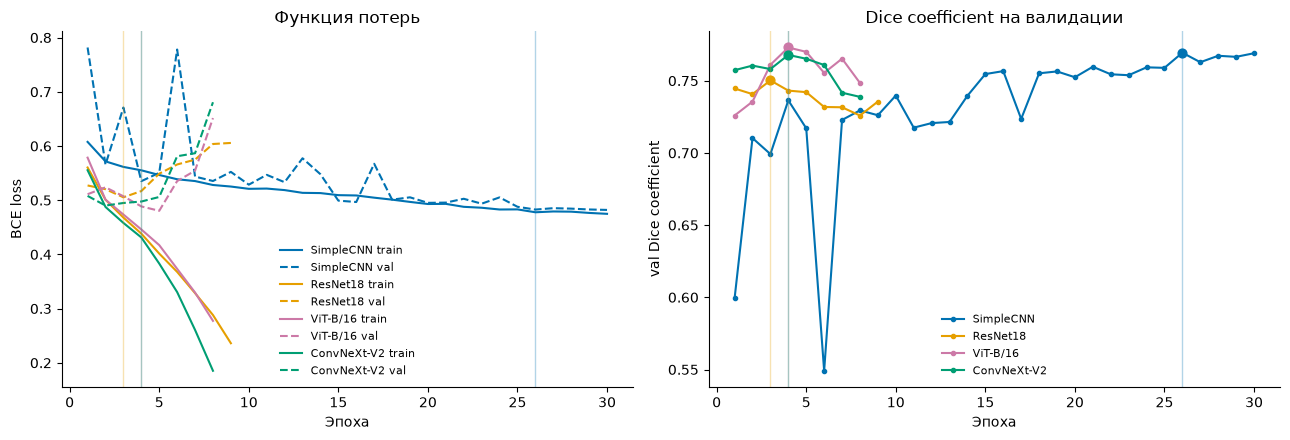

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_cnn = range(1, len(history_cnn["train_loss"]) + 1)
epochs_resnet = range(1, len(history_resnet["train_loss"]) + 1)
epochs_vit = range(1, len(history_vit["train_loss"]) + 1)
epochs_convnext = range(1, len(history_convnext["train_loss"]) + 1)

MODEL_COLORS = {
    "SimpleCNN": "#0072B2",
    "ResNet18": "#E69F00",
    "ViT-B/16": "#CC79A7",
    "ConvNeXt-V2": "#009E73",
}

axes[0].plot(epochs_cnn, history_cnn["train_loss"], color=MODEL_COLORS["SimpleCNN"], label="SimpleCNN train")
axes[0].plot(epochs_cnn, history_cnn["val_loss"], color=MODEL_COLORS["SimpleCNN"], linestyle="--", label="SimpleCNN val")
axes[0].plot(epochs_resnet, history_resnet["train_loss"], color=MODEL_COLORS["ResNet18"], label="ResNet18 train")
axes[0].plot(epochs_resnet, history_resnet["val_loss"], color=MODEL_COLORS["ResNet18"], linestyle="--", label="ResNet18 val")
axes[0].plot(epochs_vit, history_vit["train_loss"], color=MODEL_COLORS["ViT-B/16"], label="ViT-B/16 train")
axes[0].plot(epochs_vit, history_vit["val_loss"], color=MODEL_COLORS["ViT-B/16"], linestyle="--", label="ViT-B/16 val")
axes[0].plot(epochs_convnext, history_convnext["train_loss"], color=MODEL_COLORS["ConvNeXt-V2"], label="ConvNeXt-V2 train")
axes[0].plot(epochs_convnext, history_convnext["val_loss"], color=MODEL_COLORS["ConvNeXt-V2"], linestyle="--", label="ConvNeXt-V2 val")
for h, c in [(history_cnn, MODEL_COLORS["SimpleCNN"]), (history_resnet, MODEL_COLORS["ResNet18"]),
             (history_vit, MODEL_COLORS["ViT-B/16"]), (history_convnext, MODEL_COLORS["ConvNeXt-V2"])]:
    axes[0].axvline(h["best_epoch"], color=c, alpha=0.3, linewidth=1)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Функция потерь")
axes[0].legend(frameon=False, fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(epochs_cnn, history_cnn["val_dice"], color=MODEL_COLORS["SimpleCNN"], marker="o", markersize=3, label="SimpleCNN")
axes[1].plot(epochs_resnet, history_resnet["val_dice"], color=MODEL_COLORS["ResNet18"], marker="o", markersize=3, label="ResNet18")
axes[1].plot(epochs_vit, history_vit["val_dice"], color=MODEL_COLORS["ViT-B/16"], marker="o", markersize=3, label="ViT-B/16")
axes[1].plot(epochs_convnext, history_convnext["val_dice"], color=MODEL_COLORS["ConvNeXt-V2"], marker="o", markersize=3, label="ConvNeXt-V2")
for h, c in [(history_cnn, MODEL_COLORS["SimpleCNN"]), (history_resnet, MODEL_COLORS["ResNet18"]),
             (history_vit, MODEL_COLORS["ViT-B/16"]), (history_convnext, MODEL_COLORS["ConvNeXt-V2"])]:
    axes[1].axvline(h["best_epoch"], color=c, alpha=0.3, linewidth=1)
    axes[1].scatter([h["best_epoch"]], [h["best_dice"]], color=c, zorder=5, s=40)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("val Dice coefficient")
axes[1].set_title("Dice coefficient на валидации")
axes[1].legend(frameon=False, fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 15. Сравнение качества моделей

In [19]:
@torch.no_grad()
def collect_val_predictions(model, loader=val_loader):
    model.eval()
    all_logits, all_targets = [], []
    for imgs, tgts in loader:
        logits = model(imgs.to(DEVICE)).cpu()
        all_logits.append(logits)
        all_targets.append(tgts)
    return torch.cat(all_logits), torch.cat(all_targets)


logits_cnn, targets_cnn = collect_val_predictions(model_cnn)
logits_resnet, targets_resnet = collect_val_predictions(model_resnet)
logits_vit, targets_vit = collect_val_predictions(model_vit, val_loader_vit)
logits_convnext, targets_convnext = collect_val_predictions(model_convnext, val_loader_vit)

per_class_cnn = per_class_dice(logits_cnn, targets_cnn)
per_class_resnet = per_class_dice(logits_resnet, targets_resnet)
per_class_vit = per_class_dice(logits_vit, targets_vit)
per_class_convnext = per_class_dice(logits_convnext, targets_convnext)

MODEL_NAMES = ["SimpleCNN (с нуля)", "ResNet18 (transfer learning)",
               "ViT-B/16 (transfer learning)", "ConvNeXt-V2 (transfer learning)"]
HISTORIES = [history_cnn, history_resnet, history_vit, history_convnext]
PER_CLASS = [per_class_cnn, per_class_resnet, per_class_vit, per_class_convnext]

summary = pd.DataFrame({
    "model": MODEL_NAMES,
    "params_M": [h["n_params"] / 1e6 for h in HISTORIES],
    "best_epoch": [h["best_epoch"] for h in HISTORIES],
    "val_dice_samplewise": [h["best_dice"] for h in HISTORIES],
    "val_dice_mean_per_class": [np.mean(list(pc.values())) for pc in PER_CLASS],
    "train_time_min": [h["train_time_sec"] / 60 for h in HISTORIES],
})
summary

,model,params_M,best_epoch,val_dice_samplewise,val_dice_mean_per_class,train_time_min
0,SimpleCNN (с нуля),2.388772,26,0.769397,0.771138,16.317629
1,ResNet18 (transfer learning),11.178564,3,0.750212,0.755271,4.998828
2,ViT-B/16 (transfer learning),86.093572,4,0.773014,0.768042,17.360169
3,ConvNeXt-V2 (transfer learning),87.696900,4,0.767863,0.773032,25.473653


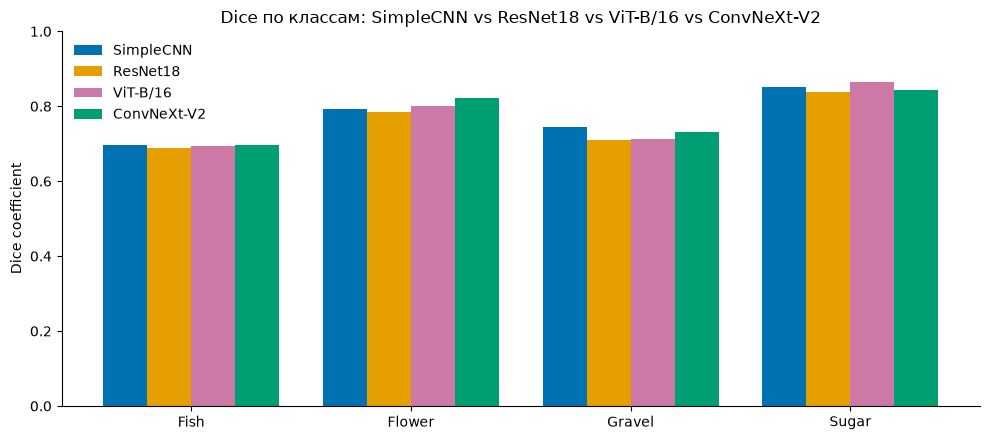

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(CLASSES))
width = 0.2
ax.bar(x - 1.5 * width, [per_class_cnn[c] for c in CLASSES], width, label="SimpleCNN", color=MODEL_COLORS["SimpleCNN"])
ax.bar(x - 0.5 * width, [per_class_resnet[c] for c in CLASSES], width, label="ResNet18", color=MODEL_COLORS["ResNet18"])
ax.bar(x + 0.5 * width, [per_class_vit[c] for c in CLASSES], width, label="ViT-B/16", color=MODEL_COLORS["ViT-B/16"])
ax.bar(x + 1.5 * width, [per_class_convnext[c] for c in CLASSES], width, label="ConvNeXt-V2", color=MODEL_COLORS["ConvNeXt-V2"])
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Dice coefficient")
ax.set_ylim(0, 1)
ax.set_title("Dice по классам: SimpleCNN vs ResNet18 vs ViT-B/16 vs ConvNeXt-V2")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 16. Проверка на валидационных снимках

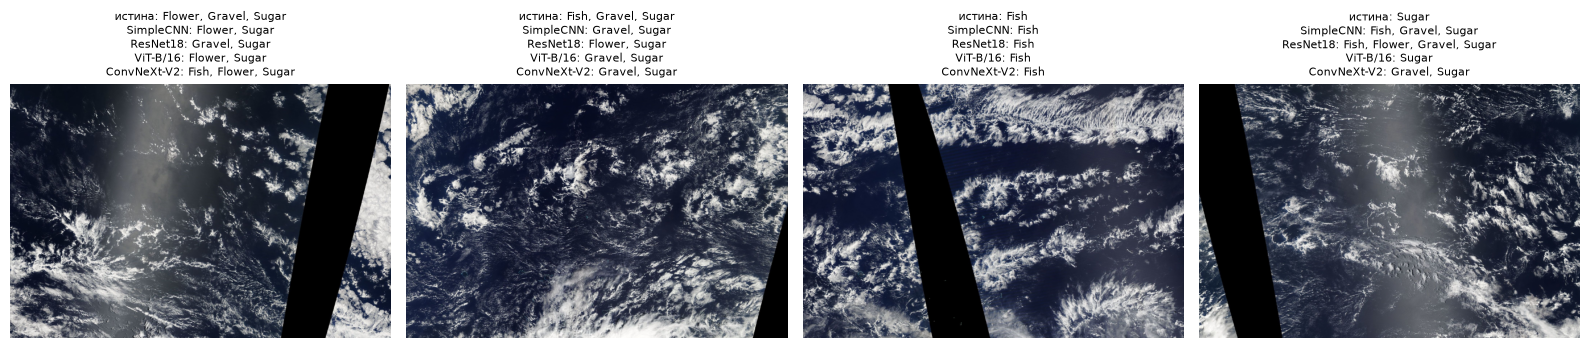

In [21]:
@torch.no_grad()
def predict_labels(model, image_id, transform=val_tf, threshold=0.5):
    img = Image.open(IMG_DIR / image_id).convert("RGB")
    x = transform(img).unsqueeze(0).to(DEVICE)
    model.eval()
    probs = torch.sigmoid(model(x)).cpu().numpy()[0]
    pred = [c for c, p in zip(CLASSES, probs) if p > threshold]
    return pred, probs


sample_val_ids = np.random.RandomState(SEED).choice(val_ids, size=4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))
for image_id, ax in zip(sample_val_ids, axes):
    pred_cnn, _ = predict_labels(model_cnn, image_id, val_tf)
    pred_resnet, _ = predict_labels(model_resnet, image_id, val_tf)
    pred_vit, _ = predict_labels(model_vit, image_id, vit_val_tf)
    pred_convnext, _ = predict_labels(model_convnext, image_id, vit_val_tf)
    true = [c for c in CLASSES if labels_df.loc[image_id, c] == 1]
    img = Image.open(IMG_DIR / image_id)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"истина: {', '.join(true)}\n"
        f"SimpleCNN: {', '.join(pred_cnn) if pred_cnn else '—'}\n"
        f"ResNet18: {', '.join(pred_resnet) if pred_resnet else '—'}\n"
        f"ViT-B/16: {', '.join(pred_vit) if pred_vit else '—'}\n"
        f"ConvNeXt-V2: {', '.join(pred_convnext) if pred_convnext else '—'}",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

## 17. Выводы

In [22]:
results = {
    "SimpleCNN (с нуля)": history_cnn,
    "ResNet18 (transfer learning)": history_resnet,
    "ViT-B/16 (transfer learning)": history_vit,
    "ConvNeXt-V2 (transfer learning)": history_convnext,
}
best_name = max(results, key=lambda k: results[k]["best_dice"])
worst_name = min(results, key=lambda k: results[k]["best_dice"])

print("Итоги сравнения моделей")
print("=" * 70)
for name, h in results.items():
    print(f"{name}: {h['n_params']/1e6:.1f}M параметров, "
          f"best val Dice = {h['best_dice']:.4f} (эпоха {h['best_epoch']}), "
          f"обучение {h['train_time_sec']/60:.1f} мин")
print("-" * 70)
print(f"Лучшее качество по Dice coefficient показала модель «{best_name}» "
      f"(разница с худшей моделью «{worst_name}»: "
      f"{results[best_name]['best_dice'] - results[worst_name]['best_dice']:.4f}).")
print(
    "ResNet18 стартует с признаков, предобученных на ImageNet, поэтому даже на "
    "относительно небольшой выборке (~5.5к снимков) он, как правило, обучается "
    "быстрее и увереннее находит текстурные признаки типов организации облаков, "
    "чем SimpleCNN, обучаемая с нуля. SimpleCNN — полностью самостоятельная "
    "архитектура без переноса знаний, и её качество ограничено объёмом "
    "обучающей выборки и глубиной сети; она может служить базовой линией "
    "(baseline), относительно которой измеряется выигрыш от transfer learning.\n\n"
    "ViT-B/16 с весами SWAG (85.3% top-1 на ImageNet, предобучение на "
    "3.6 млрд изображений) приносит на этот датасет самое сильное предобучение "
    "среди CNN/ViT-пары выше и работает на большем разрешении (384×384 против "
    "224×224 у CNN). За счёт этого self-attention-механизм трансформера видит "
    "более детальные текстуры облачных структур, но и весит на порядок больше "
    "(86M параметров против 11M у ResNet18 и 2.4M у SimpleCNN), а полный "
    "fine-tuning такой сети на выборке из ~4.7к train-снимков сильнее рискует "
    "переобучиться без масштабного домена изображений спутниковых снимков.\n\n"
    "ConvNeXt-V2-Base добавляет четвёртую точку сравнения: это тоже "
    "современная сеть на 384×384 (тот же train/val split и препроцессинг, что "
    "и у ViT-B/16 — сравнение честное), но со свёрточным, а не "
    "self-attention-механизмом. Свёртки локальны и трансляционно-инвариантны "
    "по построению, что хорошо подходит текстурным паттернам организации "
    "облаков, а предобучение FCMAE + ImageNet-22k (87.7% top-1) сильнее, чем у "
    "SWAG-весов ViT-B/16 (85.3%). На практике выбор между ResNet18, ViT-B/16 и "
    "ConvNeXt-V2 — это компромисс между качеством, объёмом вычислений на "
    "инференсе и риском переобучения на небольшом датасете."
)

Итоги сравнения моделей
SimpleCNN (с нуля): 2.4M параметров, best val Dice = 0.7694 (эпоха 26), обучение 16.3 мин
ResNet18 (transfer learning): 11.2M параметров, best val Dice = 0.7502 (эпоха 3), обучение 5.0 мин
ViT-B/16 (transfer learning): 86.1M параметров, best val Dice = 0.7730 (эпоха 4), обучение 17.4 мин
ConvNeXt-V2 (transfer learning): 87.7M параметров, best val Dice = 0.7679 (эпоха 4), обучение 25.5 мин
----------------------------------------------------------------------
Лучшее качество по Dice coefficient показала модель «ViT-B/16 (transfer learning)» (разница с худшей моделью «ResNet18 (transfer learning)»: 0.0228).
ResNet18 стартует с признаков, предобученных на ImageNet, поэтому даже на относительно небольшой выборке (~5.5к снимков) он, как правило, обучается быстрее и увереннее находит текстурные признаки типов организации облаков, чем SimpleCNN, обучаемая с нуля. SimpleCNN — полностью самостоятельная архитектура без переноса знаний, и её качество ограничено объёмом обу

## 18. Сохранение обученных моделей

In [23]:
SAVE_DIR = ROOT / "models"
SAVE_DIR.mkdir(exist_ok=True)

torch.save({
    "model_state_dict": model_cnn.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "val_dice": history_cnn["best_dice"],
    "best_epoch": history_cnn["best_epoch"],
}, SAVE_DIR / "pytorch_simplecnn_multilabel_best.pt")

torch.save({
    "model_state_dict": model_resnet.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "val_dice": history_resnet["best_dice"],
    "best_epoch": history_resnet["best_epoch"],
}, SAVE_DIR / "pytorch_resnet18_multilabel_best.pt")

torch.save({
    "model_state_dict": model_vit.state_dict(),
    "classes": CLASSES,
    "img_size": VIT_IMG_SIZE,
    "val_dice": history_vit["best_dice"],
    "best_epoch": history_vit["best_epoch"],
}, SAVE_DIR / "pytorch_vit_b16_multilabel_best.pt")

torch.save({
    "model_state_dict": model_convnext.state_dict(),
    "timm_model_name": CONVNEXT_V2_NAME,
    "classes": CLASSES,
    "img_size": VIT_IMG_SIZE,
    "val_dice": history_convnext["best_dice"],
    "best_epoch": history_convnext["best_epoch"],
}, SAVE_DIR / "pytorch_convnext_v2_multilabel_best.pt")

print("Сохранено:")
print(f"  {SAVE_DIR / 'pytorch_simplecnn_multilabel_best.pt'}  (val Dice={history_cnn['best_dice']:.4f})")
print(f"  {SAVE_DIR / 'pytorch_resnet18_multilabel_best.pt'}  (val Dice={history_resnet['best_dice']:.4f})")
print(f"  {SAVE_DIR / 'pytorch_vit_b16_multilabel_best.pt'}  (val Dice={history_vit['best_dice']:.4f})")
print(f"  {SAVE_DIR / 'pytorch_convnext_v2_multilabel_best.pt'}  (val Dice={history_convnext['best_dice']:.4f})")

Сохранено:
  /home/ubuntu/projects/ml/machine_learning_professional/hw_06/models/pytorch_simplecnn_multilabel_best.pt  (val Dice=0.7694)
  /home/ubuntu/projects/ml/machine_learning_professional/hw_06/models/pytorch_resnet18_multilabel_best.pt  (val Dice=0.7502)
  /home/ubuntu/projects/ml/machine_learning_professional/hw_06/models/pytorch_vit_b16_multilabel_best.pt  (val Dice=0.7730)
  /home/ubuntu/projects/ml/machine_learning_professional/hw_06/models/pytorch_convnext_v2_multilabel_best.pt  (val Dice=0.7679)
